# Archetypes

🧐 **What kinds of Taskmaster contestants tend to exist?**

🎯 Goal: Group contestants into interpretable performance archetypes using historical episode-level features

Approach:

1. Convert DF to one row per contestant
2. Choose and scale a small set of summary features
3. Run KMeans
4. Inspect and name the clusters

### Executive Summary

Using historical Taskmaster data, contestants were grouped into five performance archetypes based on scoring, consistency, and momentum.

These archetypes show clear separation in performance, with Elite but Chaotic and Strong & Consistent emerging as the strongest groups.

Crucially, all winners come from just these two archetypes, while other groups rarely or never win.

This suggests that Taskmaster rewards high absolute performance - either through sustained excellence or standout peak performance - rather than improvement or consistency alone.

| Archetype (Original)  | TaskLab Name        | Description                      | Example Contestants |
| --------------------- | ------------------- | -------------------------------- | ------------------- |
| Elite but Chaotic  | 🔥 The Chaos Engine    | High scoring, high variance      | Katherine Ryan, Dara Ó Briain, Liza Tarbuck |
| Strong & Consistent | 🎯 The Silent Assassin | High scoring, reliable           | Noel Fielding, Kerry Godliman, Sarah Millican |
| Chaotic Improvers  | 🌸 The Late Bloomer    | Improving, but inconsistent      | Mel Giedroyc, Asim Chaudhry, Kiell Smith-Bynoe |
| Solid but Fading   | 🏁 The Early Leader    | Strong start, declining          | Chris Ramsey, Rhod Gilbert, Guz Khan |
| Strugglers         | 🍍 The Underdog        | Low scoring, limited improvement | Julian Clary, Tim Key, Sara Pascoe |




### Imports and constants

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"

RAW_PATH = DATA_DIR / "raw"
PROCESSED_PATH = DATA_DIR / "processed"

### Load the data

In [2]:
task_df = pd.read_csv(PROCESSED_PATH / "task_clean_df.csv")

task_df.shape

(730, 12)

In [3]:
task_df.columns.tolist()

['episode',
 'episode_label',
 'contestant',
 'episode_score',
 'series_id',
 'episode_in_series',
 'cumulative_score',
 'mean_score_so_far',
 'std_score_so_far',
 'recent_avg_score',
 'momentum',
 'episodes_played']

In [4]:
task_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   episode            730 non-null    int64  
 1   episode_label      730 non-null    object 
 2   contestant         730 non-null    object 
 3   episode_score      730 non-null    int64  
 4   series_id          730 non-null    int64  
 5   episode_in_series  730 non-null    int64  
 6   cumulative_score   730 non-null    int64  
 7   mean_score_so_far  730 non-null    float64
 8   std_score_so_far   730 non-null    float64
 9   recent_avg_score   730 non-null    float64
 10  momentum           730 non-null    float64
 11  episodes_played    730 non-null    int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 68.6+ KB


## Creating Archetype clusters

### Build the archetype dataframe

In [5]:
archetype_df = (
    task_df.groupby(["series_id", "contestant"])
    .agg(
        avg_score=("episode_score", "mean"), # how strong
        avg_cumulative_score=("cumulative_score", "mean"),
        avg_std=("std_score_so_far", "mean"), # how chaotic
        avg_momentum=("momentum", "mean"), # trends
        best_episode_score=("episode_score", "max"), # ceiling
        worst_episode_score=("episode_score", "min"), # floor
        episodes_played=("episode", "count")
    )
    .reset_index()
)

archetype_df.head()

,series_id,contestant,avg_score,avg_cumulative_score,avg_std,avg_momentum,best_episode_score,worst_episode_score,episodes_played
0,1,Frank Skinner,15.500000,52.833333,4.091243,0.336111,20,9,6
1,1,Josh Widdicombe,15.666667,56.500000,3.034590,0.347222,22,9,6
2,1,Roisin Conaty,11.333333,41.000000,5.807999,-0.111111,21,7,6
3,1,Romesh Ranganathan,15.500000,57.666667,3.659558,-0.880556,22,10,6
4,1,Tim Key,14.666667,53.500000,2.342562,-1.277778,18,9,6


In [6]:
# Filter out 1 episode contestants (New Year Treat, Champion of Champions)
archetype_df = archetype_df[archetype_df["episodes_played"] > 3]

### Cluster features

In [7]:
feature_cols = [
    "avg_score",
    "avg_std",
    "avg_momentum",
    "best_episode_score",
    "worst_episode_score"
]

X = archetype_df[feature_cols]
X.head()

,avg_score,avg_std,avg_momentum,best_episode_score,worst_episode_score
0,15.500000,4.091243,0.336111,20,9
1,15.666667,3.034590,0.347222,22,9
2,11.333333,5.807999,-0.111111,21,7
3,15.500000,3.659558,-0.880556,22,10
4,14.666667,2.342562,-1.277778,18,9


In [8]:
# Scale features since KNN cares about distance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Clusters v1

In [9]:
# Start with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

archetype_df["cluster"] = kmeans.fit_predict(X_scaled)

# Inspect clusters
cluster_summary = (
    archetype_df.groupby("cluster")[feature_cols]
    .mean()
    .round(2)
)

cluster_summary

,avg_score,avg_std,avg_momentum,best_episode_score,worst_episode_score
cluster,,,,,
0,14.39,4.23,0.52,21.85,7.35
1,16.54,2.25,0.07,20.83,12.50
2,16.70,3.87,-0.35,24.46,9.85
3,13.75,2.40,-0.71,18.40,8.90


In [10]:
# ----- Optimise the number of clusters -----
# Which number gives the most meaningful groupings?

# Greater silhouette score = better separation between clusters
for k in [3, 4, 5, 6, 7, 8, 9, 10]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette_score={score:.5f}")

k=3, silhouette_score=0.24493
k=4, silhouette_score=0.24920
k=5, silhouette_score=0.23374
k=6, silhouette_score=0.24860
k=7, silhouette_score=0.26747
k=8, silhouette_score=0.27669
k=9, silhouette_score=0.23759
k=10, silhouette_score=0.22562


/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [11]:
# Inspect results
for k in [4, 5, 6, 8]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    archetype_df[f"cluster_{k}"] = kmeans.fit_predict(X_scaled)

    print(f"\n--- k={k} ---")
    print(
        archetype_df.groupby(f"cluster_{k}")[feature_cols]
        .mean()
        .round(2)
    )


--- k=4 ---
           avg_score  avg_std  avg_momentum  best_episode_score  \
cluster_4                                                         
0              14.39     4.23          0.52               21.85   
1              16.54     2.25          0.07               20.83   
2              16.70     3.87         -0.35               24.46   
3              13.75     2.40         -0.71               18.40   

           worst_episode_score  
cluster_4                       
0                         7.35  
1                        12.50  
2                         9.85  
3                         8.90  

--- k=5 ---
           avg_score  avg_std  avg_momentum  best_episode_score  \
cluster_5                                                         
0              15.79     3.66         -0.32               22.39   
1              17.52     4.12         -0.16               26.50   
2              14.20     4.40          0.65               21.90   
3              16.50     2.29         

#### 🙋‍♀️ Choosing number of clusters

Silhouette score was used to guide k, which measures how well-separated clusters are.

Scores are relatively low (~0.24–0.28) and increase with higher k, peaking at k=8. This is expected because contestant behaviour is continuous, not naturally split into distinct groups, so clusters overlap rather than forming clean boundaries.

Rather than picking the highest score, k=4, 5, 6, 8  were inspected to enable selection based on interpretability and usefulness, not just the metric. The goal was to create a small number of **clear, explainable archetypes** - avoiding complex fragmentation.

🏆 **k=5**

 k=5 has the best balance of:

- capturing meaningful differences in performance (e.g. elite vs consistent)
- keeping clusters interpretable and usable

#### Archetype summary

| Archetype             | Description                                                    |
| --------------------- | -------------------------------------------------------------- |
| 🔥 Elite but Chaotic  | Very high scoring but inconsistent - big wins and big swings   |
| ⭐ Strong & Consistent | High scoring and reliable - steady performers                  |
| 🎢 Chaotic Improvers  | Volatile but trending upwards - finding form over time         |
| 📉 Solid but Fading   | Decent performers whose results decline over time              |
| 😬 Strugglers         | Lower scoring and not improving - consistently underperforming |


In [12]:
# Add placeholder archetype names
cluster_name_map = {
    0: "Solid but Fading",
    1: "Elite but Chaotic",
    2: "Chaotic Improvers",
    3: "Strong & Consistent",
    4: "Strugglers"
}

archetype_df["archetype"] = archetype_df["cluster_5"].map(cluster_name_map)

## Inspect the archetypes

### Archetype performance

In [13]:
# What's the size of each archetype?
archetype_df["archetype"].value_counts()

archetype
Chaotic Improvers      21
Strong & Consistent    19
Solid but Fading       18
Elite but Chaotic      12
Strugglers             10
Name: count, dtype: int64

In [14]:
# What do the archetype distributions look like?
archetype_df.groupby("archetype")[[
    "avg_score",
    "avg_std",
    "avg_momentum"
]].mean().round(2)

,avg_score,avg_std,avg_momentum
archetype,,,
Chaotic Improvers,14.20,4.40,0.65
Elite but Chaotic,17.52,4.12,-0.16
Solid but Fading,15.79,3.66,-0.32
Strong & Consistent,16.50,2.29,-0.01
Strugglers,13.75,2.40,-0.71


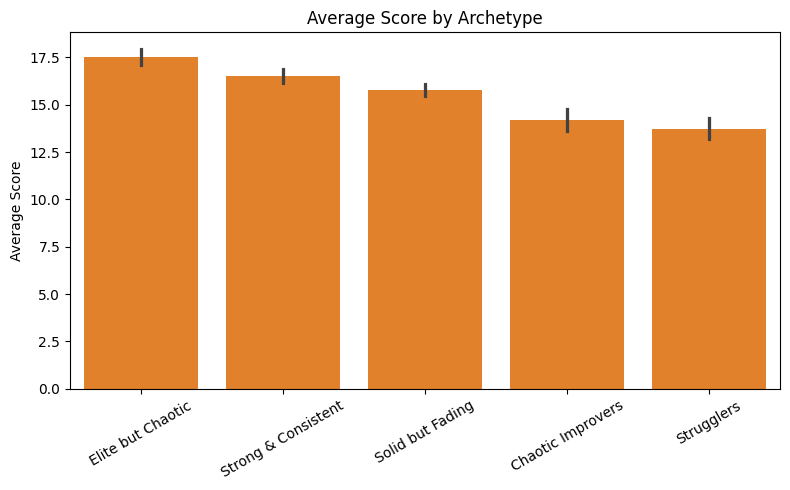

In [15]:
# Which archetypes perform best?

plt.figure(figsize=(8,5))

# Order by average score
order = (
    archetype_df.groupby("archetype")["avg_score"]
    .mean()
    .sort_values(ascending=False)
    .index
)

sns.barplot(
    data=archetype_df,
    x="archetype",
    y="avg_score",
    order=order
)

sns.barplot(
    data=archetype_df,
    x="archetype",
    y="avg_score",
    estimator="mean"
)

plt.xticks(rotation=30)
plt.title("Average Score by Archetype")
plt.ylabel("Average Score")
plt.xlabel("")

plt.tight_layout()

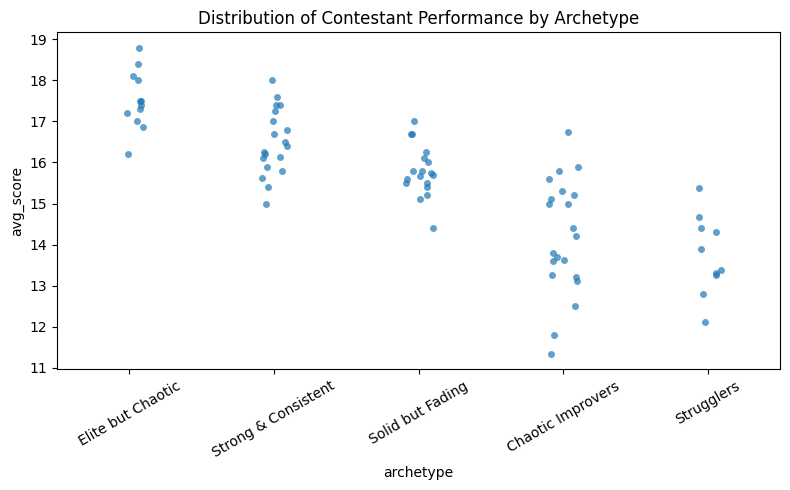

In [16]:
plt.figure(figsize=(8,5))

sns.stripplot(
    data=archetype_df,
    x="archetype",
    y="avg_score",
    order=order,
    jitter=True,
    alpha=0.7
)

plt.xticks(rotation=30)
plt.title("Distribution of Contestant Performance by Archetype")
plt.tight_layout()

plt.show()

#### Archetype outcomes

Comparing winners vs non-winners by archetype

In [17]:
# Create a series winner table
winners_df = (
    task_df.sort_values(["series_id", "episode"])
    .groupby(["series_id", "contestant"])
    .tail(1)  # last episode per contestant
)

# Rank within each series
winners_df["final_rank"] = winners_df.groupby("series_id")["cumulative_score"] \
    .rank(ascending=False, method="first")

# Mark winner
winners_df["is_winner"] = winners_df["final_rank"] == 1

# Join with archetypes
analysis_df = winners_df.merge(
    archetype_df[["series_id", "contestant", "archetype"]],
    on=["series_id", "contestant"],
    how="left"
)

# Aggregate - count winners by archetype
winner_counts = (
    analysis_df[analysis_df["is_winner"]]
    .groupby("archetype")
    .size()
    .sort_values(ascending=False)
)

winner_counts

archetype
Strong & Consistent    8
Elite but Chaotic      7
Solid but Fading       1
dtype: int64

In [18]:
# Compare proportions

archetype_summary = (
    analysis_df.groupby("archetype")
    .agg(
        total=("contestant", "count"),
        winners=("is_winner", "sum")
    )
)

archetype_summary["win_rate"] = (
    archetype_summary["winners"] / archetype_summary["total"]
)

archetype_summary.sort_values("win_rate", ascending=False)

,total,winners,win_rate
archetype,,,
Elite but Chaotic,12,7,0.583333
Strong & Consistent,19,8,0.421053
Solid but Fading,18,1,0.055556
Chaotic Improvers,21,0,0.000000
Strugglers,10,0,0.000000


#### 📊 Archetype performance analysis

The archetypes show a clear separation in performance:

- **Elite but Chaotic** and **Strong & Consistent** are the top-performing groups, with the highest average scores.
- Lower-performing archetypes — particularly **Chaotic Improvers** and **Strugglers** — lag significantly behind, despite variability or improvement over time.

This pattern is reinforced when looking at outcomes 👉 **Despite identifying five distinct archetypes, all winners come from just two groups.**

- **Elite but Chaotic** → highest win rate
- **Strong & Consistent** → second highest
- All other archetypes → rarely or never win

##### 🎯 Key insight

**Taskmaster rewards high absolute performance, not improvement or consistency alone.**

Contestants who improve over time or perform steadily at a moderate level do not typically win. Instead, success is driven by either:
- Sustained high performance (Strong & Consistent), or
- High peak performance, even if volatile (Elite but Chaotic)

##### 💡 Takeaway

Despite exploring multiple archetypes, only two consistently produce winners — suggesting that **Taskmaster rewards either sustained excellence or standout peak performance**.

## Extra: Dynamic archetypes

Are archetypes fixed identities, or do contestants evolve?

In [19]:
# Select time features that describe different state across episodes
time_features = [
    "mean_score_so_far",
    "std_score_so_far",
    "momentum"
]

# Create a clean task_df subset for dynamic clustering
dynamic_df = task_df[time_features].copy()

# Remove any infinities or missing values
dynamic_df = dynamic_df.replace([np.inf, -np.inf], np.nan).dropna()

# Remove the earliest rows where "state" is not very meaningful
# e.g. episode 1 where std_score_so_far is always 0, momentum is not very informative
dynamic_df = dynamic_df[task_df.loc[dynamic_df.index, "episodes_played"] > 1]

# Scale features
time_scaler = StandardScaler()
X_time_scaled = time_scaler.fit_transform(dynamic_df)

# Fit a NEW KMeans model for dynamic performance states
# Using 4 clusters here as robustness tweak to reduce over-fragmentation
time_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Fit the model and get one cluster label per row in dynamic_df
dynamic_labels = time_kmeans.fit_predict(X_time_scaled)

# Write the labels back to task_df
# Default new column to NaN and fill only with rows clustered
task_df["dynamic_cluster"] = np.nan
task_df.loc[dynamic_df.index, "dynamic_cluster"] = dynamic_labels

# Make the non-missing labels integers for easier reading
task_df["dynamic_cluster"] = task_df["dynamic_cluster"].astype("Int64")

# Inspect the cluster summaries
dynamic_summary = (
    task_df.dropna(subset=["dynamic_cluster"])
    .groupby("dynamic_cluster")[time_features]
    .mean()
    .round(2)
)

dynamic_summary

/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,mean_score_so_far,std_score_so_far,momentum
dynamic_cluster,,,
0,16.94,2.44,0.11
1,13.00,3.63,0.02
2,15.95,5.18,2.31
3,15.89,4.84,-2.55


👉 Episode-level clustering was explored to test whether contestants move through different performance states over time. 

The resulting clusters were interpretable, broadly separating stable high performers, weaker states, rising chaotic states, and falling chaotic states. However, sklearn produced persistent numerical warnings during fitting, so the results are being treating as an exploratory extension rather than a robust core component of the model.

## Naming the clusters

In [20]:
cluster_name_map = {
    0: "The Early Leader",
    1: "The Chaos Engine",
    2: "The Late Bloomer",
    3: "The Silent Assassin",
    4: "The Underdog"
}

archetype_df["archetype_name"] = archetype_df["cluster_5"].map(cluster_name_map)

In [21]:
archetype_df["archetype_name"].value_counts()

archetype_name
The Late Bloomer       21
The Silent Assassin    19
The Early Leader       18
The Chaos Engine       12
The Underdog           10
Name: count, dtype: int64

In [22]:
# Finding example contestants
example_df = (
    archetype_df.sort_values("avg_score", ascending=False)
    .groupby("archetype")
    .head(3)
)

example_df[["archetype", "contestant"]]

,archetype,contestant
8,Elite but Chaotic,Katherine Ryan
85,Elite but Chaotic,Dara Ó Briain
32,Elite but Chaotic,Liza Tarbuck
19,Strong & Consistent,Noel Fielding
37,Strong & Consistent,Kerry Godliman
89,Strong & Consistent,Sarah Millican
77,Solid but Fading,Chris Ramsey
18,Chaotic Improvers,Mel Giedroyc
39,Solid but Fading,Rhod Gilbert
67,Solid but Fading,Guz Khan


## Exporting artefacts

In [23]:
archetype_df[[
    "series_id",
    "contestant",
    "cluster",
    "archetype"
]].to_csv("../data/processed/archetypes.csv", index=False)

## Applying archetypes mid-series

While episode-level clustering suggested that contestant behaviour can change over time, the results were not stable enough to reliably track these transitions mid-series.

However, the earlier series-level clustering produced clear and consistent behavioural archetypes based on full-series performance.

This suggests a more pragmatic approach:

*Rather than dynamically re-clustering contestants over time, we can use these established archetypes as a stable reference point - and map current contestants to the closest behavioural pattern based on their performance so far.*

#### 🎯 Assigning archetypes to live contestants

To make the archetypes usable in a live setting, we define each one in terms of a small number of measurable behavioural features:

- **Average score** → overall performance level
- **Standard deviation** → consistency vs variability
- **Momentum** → whether performance is improving or declining

These features capture the key dimensions that distinguish the archetypes identified in the clustering step.

We then define simple rules that approximate each archetype:

| Archetype	      | Behavioural definition                   |
| --------------- | ---------------------------------------- |
| Chaos Engine	  | High average score, high variability     |
| Silent Assassin	| High average score, low variability      |  
| Late Bloomer	  | Positive momentum (improving over time)  |
| Early Leader	  | Strong average, negative momentum        |
| Underdog	      | Low average score                        |

These rules provide a lightweight and interpretable way to assign archetypes to contestants using partial-series data.

#### Why a rule-based approach?

This approach trades a small amount of precision for:

- Stability: avoids numerical issues seen in clustering
- Interpretability: aligns directly with human-readable archetypes
- Practicality: works with limited data early in a series

Importantly, the goal is not to perfectly classify contestants, but to provide a useful and intuitive lens for understanding how they are performing.

**This provides a stable, interpretable bridge between historical patterns and live series performance, enabling archetypes to be surfaced in the TaskLab app alongside win probabilities and score trajectories.**

In [24]:
# Create archetype dictionary for easy lookup

ARCHETYPE_INFO = {
    "The Chaos Engine": {
        "emoji": "🔥",
        "description": "High scoring, high variance"
        },
    "Silent Assassin": {
        "emoji": "🎯",
        "description": "High scoring, low variance"
        },
    "The Late Bloomer": {
        "emoji": "🎢",
        "description": "Improving, but inconsistent"
        },
    "The Early Leader": {
        "emoji": "🏁",
        "description": "Strong start, declining performance"
        },
    "Underdog": {
        "emoji": "🍍",
        "description": "Low scoring, limited improvement"
    }
}


In [25]:
archetype_df.columns.tolist()

['series_id',
 'contestant',
 'avg_score',
 'avg_cumulative_score',
 'avg_std',
 'avg_momentum',
 'best_episode_score',
 'worst_episode_score',
 'episodes_played',
 'cluster',
 'cluster_4',
 'cluster_5',
 'cluster_6',
 'cluster_8',
 'archetype',
 'archetype_name']

In [26]:
archetype_df["archetype_name"].unique()

array(['The Early Leader', 'The Late Bloomer', 'The Underdog',
       'The Chaos Engine', 'The Silent Assassin'], dtype=object)

In [27]:
# --- Calculate behaviour thresholds from existing archetype clusters ---

def calculate_thresholds(df, score_col="avg_score", std_col="avg_std", momentum_col="avg_momentum"):
    """
    Calculate thresholds for categorising contestants.
    """
    thresholds = {
        "score_high": df[score_col].quantile(0.6),
        "score_low": df[score_col].quantile(0.4),
        "std_high": df[std_col].quantile(0.6),
        "std_low": df[std_col].quantile(0.4),
        "momentum_high": df[momentum_col].quantile(0.6),
        "momentum_low": df[momentum_col].quantile(0.4),
        "score_mean": df[score_col].mean()
    }

    return thresholds

thresholds = calculate_thresholds(
    archetype_df,
    score_col="avg_score",
    std_col="avg_std",
    momentum_col="avg_momentum"
)

thresholds


{'score_high': np.float64(16.04),
 'score_low': np.float64(15.4),
 'std_high': np.float64(3.766388550879318),
 'std_low': np.float64(3.1561954858120056),
 'momentum_high': np.float64(0.12493650793650794),
 'momentum_low': np.float64(-0.13941666666666674),
 'score_mean': np.float64(15.543958333333336)}

In [28]:
# --- Assign archetypes based on thresholds ---

def assign_archetype(row, thresholds, score_col="avg_score", std_col="avg_std", momentum_col="avg_momentum"):
    """
    Assign an archetype to a contestant based on their performance metrics and predefined thresholds.

    Rule priority matters:
    1. Strong + chaotic -> Chaos Engine
    2. Strong + consistent -> Silent Assassin
    3. Strong but declining -> Early Leader
    4. Improving and somewhat chaotic -> Late Bloomer
    5. Lower scoring -> Underdog
    """
    score = row[score_col]
    std = row[std_col]
    momentum = row[momentum_col]

    # Rule 1: High score + high variance = Chaos Engine
    if score >= thresholds["score_high"] and std >= thresholds["std_high"]:
        return "The Chaos Engine"

    # Rule 2: High score + low variance = Silent Assassin
    elif score >= thresholds["score_high"] and std <= thresholds["std_low"]:
        return "Silent Assassin"

    # Rule 3: High score but declining = Early Leader
    elif score < thresholds["score_mean"] and momentum >= thresholds["momentum_high"]:
        return "The Late Bloomer"

    # Rule 4: Improving and somewhat chaotic = Late Bloomer
    elif score >= thresholds["score_high"] and momentum <= thresholds["momentum_low"]:
        return "The Early Leader"

    # Rule 5: Lower scoring = Underdog
    else:
        return "The Underdog"

    # Fallback to nearest simple rule if no conditions met
    if momentum > 0:
        return "Late Bloomer"
    else:
        return "The Underdog"

archetype_df["rule_based_archetype"] = archetype_df.apply(
    assign_archetype,
    axis=1,
    thresholds=thresholds,
    score_col="avg_score",
    std_col="avg_std",
    momentum_col="avg_momentum"
)

In [29]:
# Compare rule-based archetypes with KMeans archetypes
archetype_df[["contestant", "archetype_name", "rule_based_archetype"]].head(10)

,contestant,archetype_name,rule_based_archetype
0,Frank Skinner,The Early Leader,The Late Bloomer
1,Josh Widdicombe,The Early Leader,The Underdog
2,Roisin Conaty,The Late Bloomer,The Underdog
3,Romesh Ranganathan,The Early Leader,The Underdog
4,Tim Key,The Underdog,The Underdog
5,Doc Brown,The Late Bloomer,The Underdog
6,Joe Wilkinson,The Late Bloomer,The Late Bloomer
7,Jon Richardson,The Chaos Engine,The Early Leader
8,Katherine Ryan,The Chaos Engine,The Chaos Engine
9,Richard Osman,The Chaos Engine,The Chaos Engine


In [30]:
# Confusion matrix to compare the two archetype assignments
pd.crosstab(
    archetype_df["archetype_name"],
    archetype_df["rule_based_archetype"]
)

rule_based_archetype,Silent Assassin,The Chaos Engine,The Early Leader,The Late Bloomer,The Underdog
archetype_name,,,,,
The Chaos Engine,1,8,2,0,1
The Early Leader,1,1,1,1,14
The Late Bloomer,0,1,0,11,9
The Silent Assassin,14,0,0,2,3
The Underdog,0,0,0,0,10


In [31]:
# Accuracy of rule-based archetypes compared to KMeans archetypes
accuracy = np.mean(archetype_df["archetype_name"] == archetype_df["rule_based_archetype"])
print(f"Rule-based archetype accuracy: {accuracy:.2%}")

Rule-based archetype accuracy: 37.50%


#### 🙋‍♀️ Rule-based archetypes show partial alignment, but struggle with trajectory-driven behaviour

The rule-based approach achieves **~37% agreement** with the original cluster-derived archetypes. This indicates that simple thresholds capture some of the underlying structure - particularly for more clearly defined groups:

- Silent Assassin and Underdog are identified reliably, as they are strongly separated by score level and consistency
- Archetypes that depend on how performance evolves over time, such as Early Leader and Late Bloomer, are frequently misclassified
  - Early Leaders are often labelled as Underdogs, suggesting that the rules overweight current score and fail to capture prior strength
  - Late Bloomers are sometimes misidentified as Underdogs for similar reasons, as early low scores dominate the signal

👉 This highlights an important **limitation**: While rule-based thresholds can approximate simple behavioural patterns, they struggle to represent archetypes that depend on interactions between features, especially trajectory over time.

The clustering approach implicitly captures these interactions, whereas the rule-based system treats each dimension more independently.

### Archetype-informed rules

Archetypes are better understood as regions in a multi-dimensional behavioural space, defined by combinations of score, consistency, and trajectory.

So instead of attempting to further tune thresholds, we'll follow a more robust assignment approach:

- Represent each archetype by its centroid (average behaviour across historical contestants)
- Assign new contestants based on distance to these archetypes

This preserves the structure discovered during clustering, while remaining stable and interpretable for live use.

In [32]:
centroids = archetype_df.groupby("archetype_name")[[
    "avg_score",
    "avg_std",
    "avg_momentum"
]].mean().round(2)

centroids

,avg_score,avg_std,avg_momentum
archetype_name,,,
The Chaos Engine,17.52,4.12,-0.16
The Early Leader,15.79,3.66,-0.32
The Late Bloomer,14.20,4.40,0.65
The Silent Assassin,16.50,2.29,-0.01
The Underdog,13.75,2.40,-0.71


In [33]:
# Fit scaler on the original features to get the same scaling as KMeans
centroid_feature_cols = ["avg_score", "avg_std", "avg_momentum"]

scaler = StandardScaler()
scaler.fit(archetype_df[centroid_feature_cols])

raw_centroids = archetype_df.groupby("archetype_name")[centroid_feature_cols].mean()

centroids = pd.DataFrame(
    scaler.transform(raw_centroids),
    columns=centroid_feature_cols,
    index=raw_centroids.index
).round(2)

centroids

,avg_score,avg_std,avg_momentum
archetype_name,,,
The Chaos Engine,1.23,0.62,-0.19
The Early Leader,0.15,0.20,-0.41
The Late Bloomer,-0.84,0.87,0.90
The Silent Assassin,0.59,-1.05,0.02
The Underdog,-1.12,-0.94,-0.93


In [34]:
# Assign archetype based on distance to KMeans centroids
def assign_nearest_archetype(row, centroids, scaler):

    best_archetype = None
    best_distance = float("inf")    # positive infinity as initial best distance

    # Loop through each archetype centroid and calculate distance
    for archetype_name, centroid in centroids.iterrows():

        # Scale the contestant's features using the same scaler
        contestant_features = pd.DataFrame([{
        "avg_score": row["avg_score"],
        "avg_std": row["avg_std"],
        "avg_momentum": row["avg_momentum"]
    }])

        scaled_contestant_features = scaler.transform(contestant_features)[0]

        # Calculate Euclidean distance to the centroid
        distance = np.linalg.norm(scaled_contestant_features - centroid)

        # Update best archetype if this one is closer
        if distance < best_distance:
            best_distance = distance
            best_archetype = archetype_name

    return best_archetype

archetype_df["centroid_archetype"] = archetype_df.apply(
    assign_nearest_archetype,
    axis=1,
    centroids=centroids,
    scaler=scaler
)

pd.crosstab(archetype_df["archetype_name"], archetype_df["centroid_archetype"])

centroid_archetype,The Chaos Engine,The Early Leader,The Late Bloomer,The Silent Assassin,The Underdog
archetype_name,,,,,
The Chaos Engine,9,0,1,2,0
The Early Leader,2,13,1,1,1
The Late Bloomer,1,0,20,0,0
The Silent Assassin,0,2,0,17,0
The Underdog,0,0,0,0,10


In [35]:
# Accuracy of centroid archetypes compared to KMeans archetypes
accuracy = np.mean(archetype_df["archetype_name"] == archetype_df["centroid_archetype"])
print(f"Centroid-based archetype accuracy: {accuracy:.2%}")

Centroid-based archetype accuracy: 86.25%


#### 🙋‍♀️ Centroid-based assignment closely recovers cluster-derived archetypes

Using a centroid-based approach - where each archetype is represented by its average position in feature space - results in strong alignment with the original clustering. This method results in **86% agreement* with cluster-derived archetypes, and consistent recovery across all major archetypes, particularly Late Bloomer, Silent Assassin and Underdog.

This represents a significant improvement over the rule-based approach (~37% agreement), which struggled to capture interactions between features and trajectory-based behaviour.

👉 **This confirms that archetypes are best understood as regions in a multi-dimensional behavioural space, rather than simple threshold-based categories.**

The centroid-based method preserves the structure learned during clustering, and the relationships between score, consistency, and trajectory. It offers a stable and efficient approach for assigning new contestants.

✅ Archetype assignment in the live app will use centroid-based matching, ensuring consistency with historical patterns while remaining interpretable and lightweight.

## Exports

In [36]:
centroids.to_csv("../data/processed/archetype_centroids.csv")

In [37]:
scaler_params = pd.DataFrame({
    "feature": centroid_feature_cols,
    "mean": scaler.mean_,
    "std": scaler.scale_
})

scaler_params.to_csv("../data/processed/archetype_scaler.csv", index=False)

In [38]:
# Checks
test_centroids = pd.read_csv("../data/processed/archetype_centroids.csv", index_col=0)
test_scaler = pd.read_csv("../data/processed/archetype_scaler.csv")

print(test_centroids.head())
print(test_scaler)

                     avg_score  avg_std  avg_momentum
archetype_name                                       
The Chaos Engine          1.23     0.62         -0.19
The Early Leader          0.15     0.20         -0.41
The Late Bloomer         -0.84     0.87          0.90
The Silent Assassin       0.59    -1.05          0.02
The Underdog             -1.12    -0.94         -0.93
        feature       mean       std
0     avg_score  15.543958  1.609348
1       avg_std   3.440151  1.104129
2  avg_momentum  -0.017764  0.742023


### Charts

In [50]:
centroids.columns.tolist()

['avg_score', 'avg_std', 'avg_momentum']

In [55]:
centroids_chart = centroids.copy().reset_index()

# Scale scoring to 0–1 (higher = better)
centroids_chart["scoring_scaled"] = (
    (centroids_chart["avg_score"] - centroids_chart["avg_score"].min()) /
    (centroids_chart["avg_score"].max() - centroids_chart["avg_score"].min())
)

# Scale consistency to 0–1 (higher = more consistent / stable)
centroids_chart["consistency_scaled"] = 1 - (
    (centroids_chart["avg_std"] - centroids_chart["avg_std"].min()) /
    (centroids_chart["avg_std"].max() - centroids_chart["avg_std"].min())
)

# Momentum direction helper
def momentum_arrow(m):
    if m > 0.1:
        return "↑"
    elif m < -0.1:
        return "↓"
    else:
        return "→"

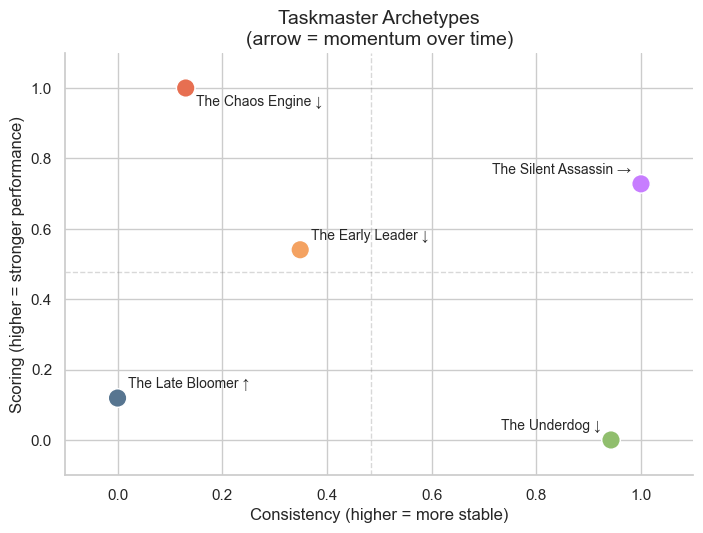

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

archetype_palette = {
    "The Chaos Engine": "#e76f51",
    "The Silent Assassin": "#c77dff",
    "The Late Bloomer": "#577590",
    "The Early Leader": "#f4a261",
    "The Underdog": "#90be6d",
}

# Plot
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7.5, 5.8))

sns.scatterplot(
    data=centroids_chart,
    x="consistency_scaled",
    y="scoring_scaled",
    hue="archetype_name",
    palette=archetype_palette,
    s=180,
    legend=False,
    ax=ax
)

# Add quadrant guide lines
ax.axhline(
    centroids_chart["scoring_scaled"].mean(),
    linestyle="--",
    linewidth=1,
    alpha=0.3,
    color="gray"
)
ax.axvline(
    centroids_chart["consistency_scaled"].mean(),
    linestyle="--",
    linewidth=1,
    alpha=0.3,
    color="gray"
)

# Manual label offsets to reduce crowding
for _, row in centroids_chart.iterrows():
    x = row["consistency_scaled"]
    y = row["scoring_scaled"]

    # smart alignment based on position
    ha = "left" if x < 0.75 else "right"
    va = "bottom" if y < 0.85 else "top"

    ax.text(
        x + (0.02 if ha == "left" else -0.02),
        y + (0.02 if va == "bottom" else -0.02),
        f"{row['archetype_name']} {momentum_arrow(row['avg_momentum'])}",
        fontsize=10,
        ha=ha,
        va=va
    )

# Titles and labels
ax.set_title("Taskmaster Archetypes\n(arrow = momentum over time)", fontsize=14)
ax.set_xlabel("Consistency (higher = more stable)")
ax.set_ylabel("Scoring (higher = stronger performance)")

# Padding around edges
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)

sns.despine()
plt.tight_layout(pad=2)

plt.tight_layout(pad=2)

plt.savefig(
    "archetypes_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()